<a href="https://colab.research.google.com/github/Aymankhadija/ML-Models/blob/main/Package_Price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
import seaborn as sns

In [5]:
df = pd.read_csv("/content/mobile_package_price.csv")
df

,Data_MB,Call_Minutes,SMS_Count,Validity_Days,Internet_Speed_Mbps,Customer_Age,Package_Price
0,1000,100,500,7,10,20,150
1,2000,200,1000,15,20,25,300
2,5000,500,2000,30,50,30,800
3,1500,150,700,10,15,22,220
4,3000,300,1200,20,25,28,450
5,6000,600,2500,30,60,35,950
6,2500,250,900,15,20,24,350
7,4000,400,1500,25,35,27,600
8,7000,700,3000,30,70,40,1100
9,1200,120,600,7,12,21,180


In [6]:
df.columns

Index(['Data_MB', 'Call_Minutes', 'SMS_Count', 'Validity_Days',
       'Internet_Speed_Mbps', 'Customer_Age', 'Package_Price'],
      dtype='object')

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Data_MB              15 non-null     int64
 1   Call_Minutes         15 non-null     int64
 2   SMS_Count            15 non-null     int64
 3   Validity_Days        15 non-null     int64
 4   Internet_Speed_Mbps  15 non-null     int64
 5   Customer_Age         15 non-null     int64
 6   Package_Price        15 non-null     int64
dtypes: int64(7)
memory usage: 972.0 bytes


In [8]:
df.describe()

,Data_MB,Call_Minutes,SMS_Count,Validity_Days,Internet_Speed_Mbps,Customer_Age,Package_Price
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,3766.666667,376.666667,1573.333333,20.266667,36.000000,28.733333,580.666667
std,2189.476998,218.947700,912.192544,9.011633,22.245385,6.713171,352.348583
min,1000.000000,100.000000,500.000000,7.000000,10.000000,20.000000,150.000000
25%,1900.000000,190.000000,850.000000,12.500000,19.000000,23.500000,280.000000
50%,3500.000000,350.000000,1400.000000,20.000000,30.000000,28.000000,520.000000
75%,5250.000000,525.000000,2100.000000,30.000000,52.500000,32.500000,840.000000
max,8000.000000,800.000000,3500.000000,30.000000,80.000000,42.000000,1250.000000


In [9]:
df.isna().sum()


,0
Data_MB,0
Call_Minutes,0
SMS_Count,0
Validity_Days,0
Internet_Speed_Mbps,0
Customer_Age,0
Package_Price,0


In [10]:
df.drop(columns=['Customer_Age'], inplace=True)
df.head()

,Data_MB,Call_Minutes,SMS_Count,Validity_Days,Internet_Speed_Mbps,Package_Price
0,1000,100,500,7,10,150
1,2000,200,1000,15,20,300
2,5000,500,2000,30,50,800
3,1500,150,700,10,15,220
4,3000,300,1200,20,25,450


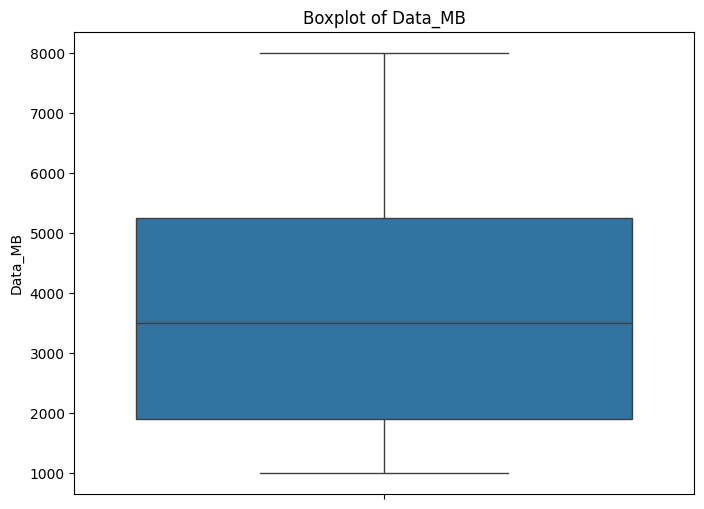

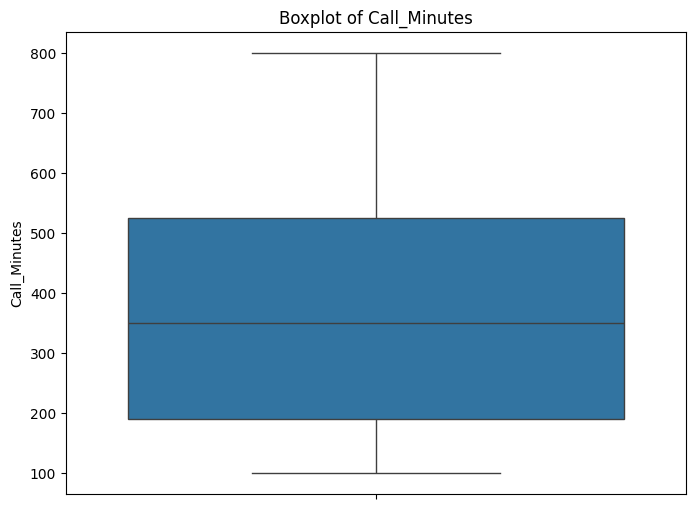

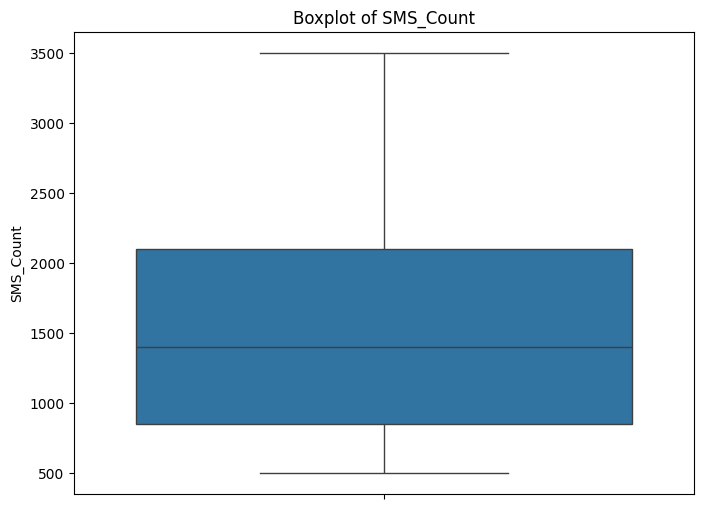

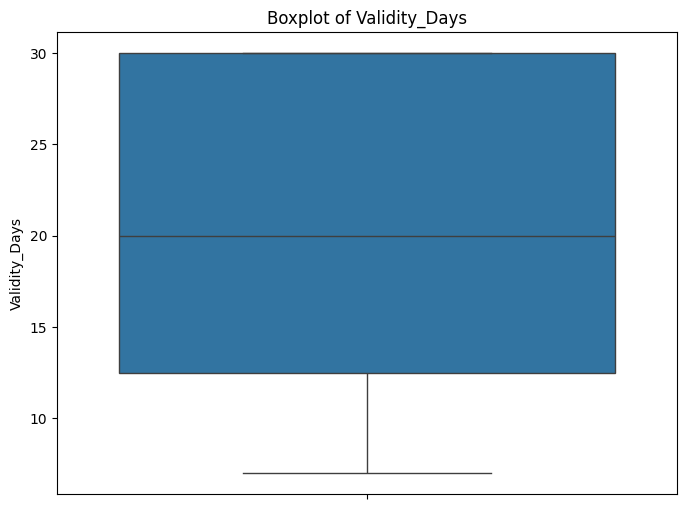

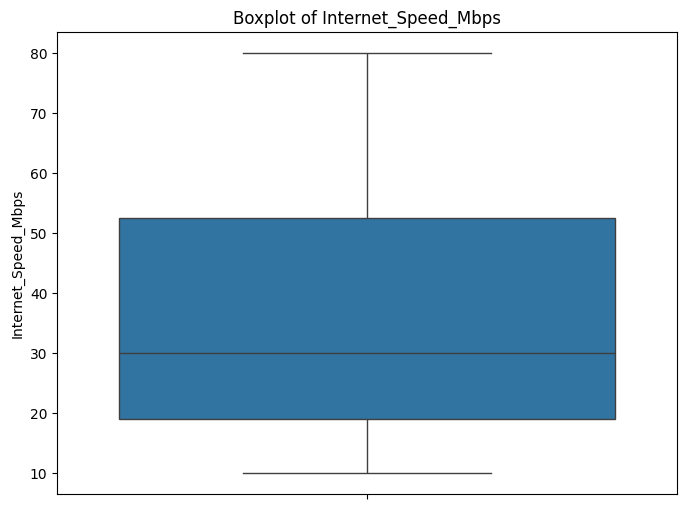

In [11]:
input_features = ["Data_MB","Call_Minutes","SMS_Count","Validity_Days","Internet_Speed_Mbps"]

for feature in input_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.ylabel(feature)
    plt.show()

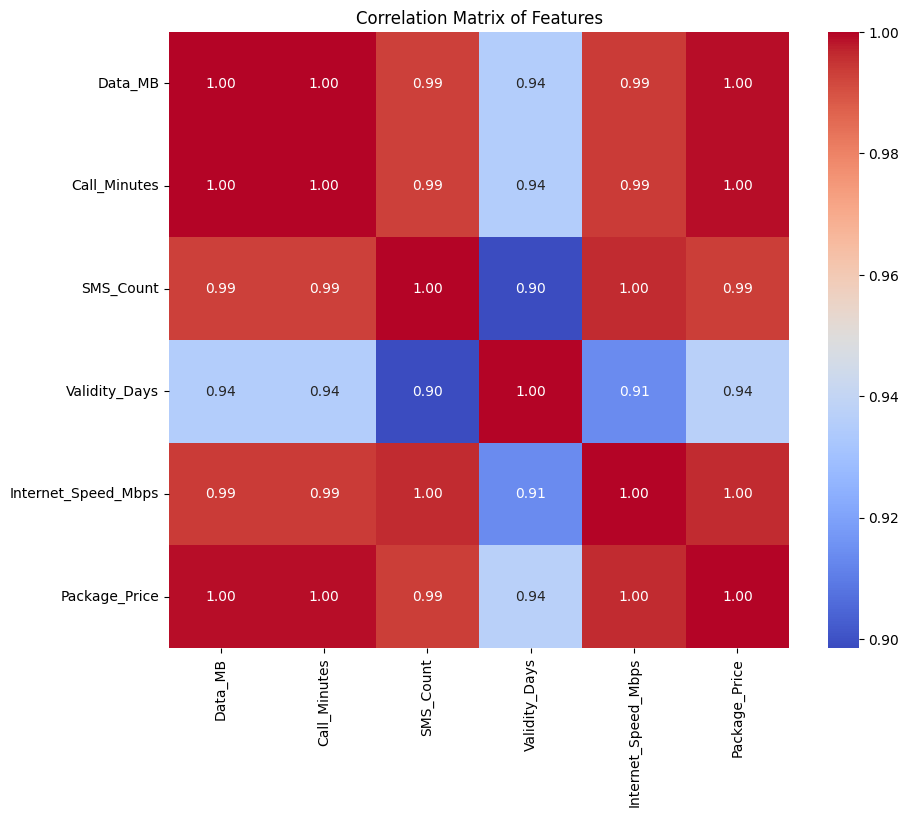

In [12]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

In [13]:
lr = linear_model.LinearRegression()

In [14]:
lr.fit(df[["Data_MB","Call_Minutes","SMS_Count","Validity_Days","Internet_Speed_Mbps"]],df.Package_Price)

LinearRegression()

In [15]:
lr.predict([[7000,700,3000,30,70]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1101.39415776])

In [16]:
lr.predict([[10000,700,5000,45,100]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1584.4604262])

In [17]:
lr.coef_

array([ 9.67747728e-02,  9.67747728e-03, -3.60745987e-03,  2.30887178e+00,
        5.51079310e+00])

In [18]:
lr.intercept_

np.float64(-27.002776904088932)

In [19]:
package_price =9.67747728e-02* 10000 +   9.67747728e-03*700 -3.60745987e-03*5000 +   2.30887178e+00*45 + 5.51079310e+00*100 -43.138529599886624

In [20]:
package_price

1568.3246732461134

In [21]:
lr.score(df[["Data_MB","Call_Minutes","SMS_Count","Validity_Days","Internet_Speed_Mbps"]],df.Package_Price)

0.9995298024289306

In [22]:
!pip install streamlit
import streamlit as st

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 21.9 MB/s eta 0:00:00


In [23]:
!pip install gradio

In [29]:
import pickle
with open("/content/drive/MyDrive/Colab Notebooks/package_price_model.pkl", "wb") as f:
    pickle.dump(lr, f)

In [30]:
with open("/content/drive/MyDrive/Colab Notebooks/package_price_model.pkl", "rb") as f:
    lr2 = pickle.load(f)

In [26]:
lr2.predict([[10000,700,5000,45,100]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1584.4604262])

In [27]:
import gradio as gr

def predict_price(data_mb, call_minutes, sms_count,
                  validity_days, internet_speed):

    prediction = lr.predict([[
        data_mb,
        call_minutes,
        sms_count,
        validity_days,
        internet_speed

    ]])

    return f"Rs. {prediction[0]:,.2f}"

with gr.Blocks(
    theme=gr.themes.Soft(),
    title="Mobile Package Price Prediction"
) as app:

    gr.Markdown("""
    # 📱 Mobile Package Price Prediction

    Predict the price of a mobile package using Machine Learning.

    Enter the package details below and click **Predict Price**.
    """)

    with gr.Row():
        with gr.Column():
            data_mb = gr.Number(label="📶 Data (MB)")
            call_minutes = gr.Number(label="📞 Call Minutes")
            sms_count = gr.Number(label="💬 SMS Count")

        with gr.Column():
            validity_days = gr.Number(label="📅 Validity (Days)")
            internet_speed = gr.Number(label="⚡ Internet Speed (Mbps)")


    predict_btn = gr.Button("🚀 Predict Price")

    output = gr.Textbox(
        label="💰 Predicted Package Price",
        interactive=False
    )

    predict_btn.click(
        predict_price,
        inputs=[
            data_mb,
            call_minutes,
            sms_count,
            validity_days,
            internet_speed

        ],
        outputs=output
    )


/tmp/ipykernel_1425/1757486647.py:17: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(


In [28]:
-
app.launch()

SyntaxError: invalid syntax (3516059356.py, line 1)